In [14]:
# import libraries
import json
from sklearn.model_selection import train_test_split, KFold
from transformers import AutoTokenizer, AutoModelForTokenClassification, logging
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.optim import AdamW
import sys
from pathlib import Path
import optuna
from functools import partial
import matplotlib.pyplot as plt
import numpy as np

# suppress unproblematic warnings from transformer models
logging.set_verbosity_error()

# change path to the project root
base_path = Path.cwd() / "../../"
sys.path.append(str(base_path.resolve()))

# load custom functions
from utils.classification import EarlyStopping, train_bert, tune_bert_ner_optuna
from utils.evaluation import run_testset_ner, evaluate_seqeval, mention_level_evaluation, sentence_level_evaluation

In [2]:
# load the annotated data in json format
with open("../../01_data/annotations_reduced.json", "r") as f:
    data = json.load(f)

# initialize tag dictionary
tag_dict = {"O"}

# loop through all sentences
for task in data:
    if task["annotations"]:
        for annotation in task["annotations"]:
            label = annotation["tag"][0:2]
            tag_dict.add(f"B-{label}")
            tag_dict.add(f"I-{label}")

# sort the tag dictionary
tag_list = sorted(tag_dict)

# dictionaries that convert from id to tag and vice versa
tag_to_id = {tag: i for i, tag in enumerate(tag_list)}
id_to_tag = {id: label for label, id in tag_to_id.items()}

In [3]:
# function that creates BIO-tags for text
def bert_tokenization_labelling(text, entities, tokenizer, tag2id, max_len):

    # tokenize and get offsets
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True, max_length=max_len, padding="max_length")
    
    # initialize label list with as many "O" labels as there are tokens
    tags = ["O"] * len(encoding.offset_mapping)
    
    # loop through all spans, get start and end position as well as the label
    for ent in entities:
        start, end = ent["start"], ent["end"]
        ent_tag = ent["tag"][0:2]
        
        # loop through all tokens in the sentence
        for idx, (token_start, token_end) in enumerate(encoding.offset_mapping):

            # if token is at the start of the annotation, this is the B token
            if token_start == start:
                tags[idx] = f"B-{ent_tag}"
            # if token starts after the start and before the end (end is character after the last) this is an I token
            if token_start > start and token_end <= end:
                tags[idx] = f"I-{ent_tag}"

    # convert tags to IDs, using -100 for padding/special tokens
    tag_ids = [-100 if word_id is None else tag2id.get(tag, tag2id["O"]) for tag, word_id in zip(tags, encoding.word_ids())]

    return encoding["input_ids"], encoding["attention_mask"], tag_ids, encoding.word_ids()

In [5]:
# split into training, validation and test dataset
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

class TokenDataset(Dataset):
    def __init__(self, data, tokenizer, tag2id, max_len=128):
        self.dataset = []
        self.max_len = max_len

        for task in data:
            # get the sentence and all annotations
            text = task["sentence"]
            spans = task["annotations"]

            # tokenize and get all ids
            input_ids, attention_mask, tag_ids, word_ids = bert_tokenization_labelling(text, spans, tokenizer, tag2id, max_len=self.max_len)

            # add everything to the dataset list
            self.dataset.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
                "tag_ids": torch.tensor(tag_ids, dtype=torch.long),
                "word_ids": word_ids})
  

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

def custom_collate_fn(batch):
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_masks = torch.stack([item["attention_mask"] for item in batch])
    tag_ids = torch.stack([item["tag_ids"] for item in batch])
    word_ids = [item["word_ids"] for item in batch]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "tag_ids": tag_ids,
        "word_ids": word_ids
    }

In [7]:
# try out TPE search algorithm

def objective(trial, model_name, train_dataset, val_dataset, collate_fn, tag2id, id2tag, device, early_stopper):
    params = {
        "lr": trial.suggest_categorical("lr", [9e-6, 2e-5, 4e-5]),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_categorical("weight_decay", [0.01, 0.1, 0.3]),
        "epochs": trial.suggest_categorical("epochs", [2, 2, 2])
    }

    best_f1, best_epoch, train_losses, val_losses, f1_scores_train, f1_scores_val = tune_bert_ner_optuna(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        collate_fn=collate_fn,
        model_name=model_name,
        tag2id=tag2id,
        id2tag=id2tag,
        device=device,
        early_stopper=early_stopper,
        params=params
    )

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)
    trial.set_user_attr("f1_scores_train", f1_scores_train)
    trial.set_user_attr("f1_scores_val", f1_scores_val)

    return best_f1

optimal_configs = {}
num_trials = 2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_names = ["roberta-base", "bert-base-cased", "distilbert-base-cased"]

for model_name in model_names:

    print(f"\nStarting search for model: {model_name}")
    print("-"*200)

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = TokenDataset(data=train_data, tokenizer=tokenizer, tag2id=tag_to_id)
    val_dataset = TokenDataset(data=val_data, tokenizer=tokenizer, tag2id=tag_to_id)
    study.optimize(
        partial(objective,
                model_name=model_name,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                collate_fn=custom_collate_fn,
                tag2id=tag_to_id,
                id2tag=id_to_tag,
                device=device,
                early_stopper=EarlyStopping(patience=3, path=f"model_saves/{model_name}_checkpoint", printoption=True)),
        n_trials=num_trials
    )
    best_trial = study.best_trial
    optimal_configs[model_name] = {
        "best_f1": best_trial.value,
        "best_params": best_trial.params,
        "best_epoch": best_trial.user_attrs["best_epoch"],
        "train_losses": best_trial.user_attrs["train_losses"],
        "val_losses": best_trial.user_attrs["val_losses"],
        "f1_scores_train": best_trial.user_attrs["f1_scores_train"],
        "f1_scores_val": best_trial.user_attrs["f1_scores_val"]
    }
    print("-"*200)

[I 2025-11-04 16:40:11,696] A new study created in memory with name: no-name-6e30300b-5147-4b6a-9a0e-30f50813cff9



Starting search for model: roberta-base
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Trial with params: {'lr': 9e-06, 'batch_size': 16, 'weight_decay': 0.01, 'epochs': 2}
Epoch 1/2


Training: 100%|██████████| 5/5 [00:02<00:00,  2.03it/s, loss=0.728]


Average training loss: 0.8928
Validation F1 increased (0.000000 --> 0.000000).  Saving model ...
Epoch 2/2


Training: 100%|██████████| 5/5 [00:02<00:00,  2.46it/s, loss=0.432]


...

Average training loss: 1.0504
Epoch 2/2


Training: 100%|██████████| 3/3 [00:00<00:00,  3.10it/s, loss=0.556]


Average training loss: 0.6719


[I 2025-11-04 16:40:50,098] Trial 1 finished with value: 0.0 and parameters: {'lr': 2e-05, 'batch_size': 32, 'weight_decay': 0.01, 'epochs': 2}. Best is trial 0 with value: 0.0.


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


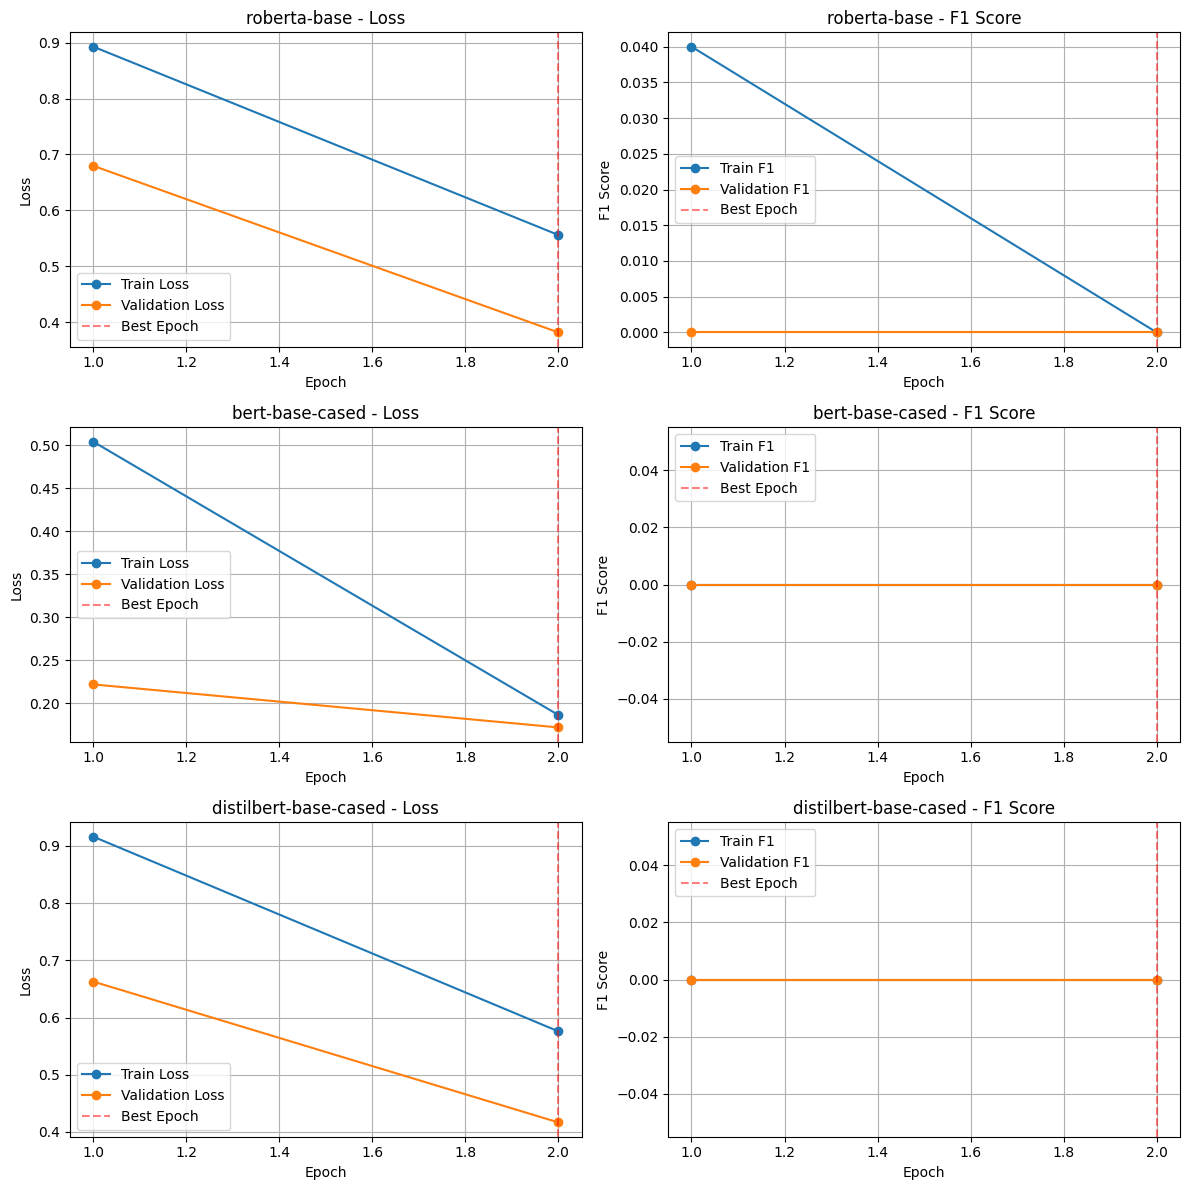

In [9]:
# plot the development of F1 scores and losses for the tuned models

model_names = list(optimal_configs.keys())
num_models = len(model_names)

fig, axes = plt.subplots(num_models, 2, figsize=(12, 4 * num_models))  # 2 columns: loss, F1

for i, model_name in enumerate(model_names):
    config = optimal_configs[model_name]
    epochs = list(range(1, len(config['train_losses']) + 1))

    # ----- Loss subplot -----
    ax_loss = axes[i, 0] if num_models > 1 else axes[0]
    ax_loss.plot(epochs, config['train_losses'], marker='o', label='Train Loss')
    ax_loss.plot(epochs, config['val_losses'], marker='o', label='Validation Loss')
    ax_loss.axvline(config['best_epoch'] + 1, linestyle='--', color='red', alpha=0.5, label='Best Epoch')
    ax_loss.set_title(f"{model_name} - Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    # ----- F1 subplot -----
    ax_f1 = axes[i, 1] if num_models > 1 else axes[1]
    ax_f1.plot(epochs, config['f1_scores_train'], marker='o', label='Train F1')
    ax_f1.plot(epochs, config['f1_scores_val'], marker='o', label='Validation F1')
    ax_f1.axvline(config['best_epoch'] + 1, linestyle='--', color='red', alpha=0.5, label='Best Epoch')
    ax_f1.set_title(f"{model_name} - F1 Score")
    ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylabel("F1 Score")
    ax_f1.legend()
    ax_f1.grid(True)

plt.tight_layout()
plt.show()

In [12]:
optimal_configs

{'roberta-base': {'best_f1': 0.0,
  'best_params': {'lr': 9e-06,
   'batch_size': 16,
   'weight_decay': 0.01,
   'epochs': 2},
  'best_epoch': 1,
  'train_losses': [0.8927764058113098, 0.5559813737869262],
  'val_losses': [0.67971470952034, 0.381780281662941],
  'f1_scores_train': [0.039999999999999994, 0.0],
  'f1_scores_val': [0.0, 0.0]},
 'bert-base-cased': {'best_f1': 0.0,
  'best_params': {'lr': 2e-05,
   'batch_size': 8,
   'weight_decay': 0.3,
   'epochs': 2},
  'best_epoch': 1,
  'train_losses': [0.5040490090847015, 0.18613189533352853],
  'val_losses': [0.22173629701137543, 0.17169605195522308],
  'f1_scores_train': [0.0, 0.0],
  'f1_scores_val': [0.0, 0.0]},
 'distilbert-base-cased': {'best_f1': 0.0,
  'best_params': {'lr': 2e-05,
   'batch_size': 32,
   'weight_decay': 0.1,
   'epochs': 2},
  'best_epoch': 1,
  'train_losses': [0.9162951906522115, 0.5758376816908518],
  'val_losses': [0.6629647612571716, 0.41667479276657104],
  'f1_scores_train': [0.0, 0.0],
  'f1_scores_va

In [11]:
# apply cross validation to all models with their best hyperparameters

model_names = ["roberta-base", "bert-base-cased", "distilbert-base-cased"]

# empty dictionary to store the metrics on the test set
test_metrics = {}

for model_name in model_names:

    # save the individual evaluation metrics
    fold_metrics = {
        "seqeval": [],
        "cross_span": [],
        "sentence_level": []
    }

    # get the optimal hyperparameters for this model
    epochs = optimal_configs[model_name]["best_epoch"]
    lr = optimal_configs[model_name]["best_params"]["lr"]
    batch_size = optimal_configs[model_name]["best_params"]["batch_size"]
    weight_decay = optimal_configs[model_name]["best_params"]["weight_decay"]

    # define the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    k = 5
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
        train_fold_data = [train_data[i] for i in train_idx]
        val_fold_data = [train_data[i] for i in val_idx]

        train_dataset = TokenDataset(data=train_fold_data, tokenizer=tokenizer, tag2id=tag_to_id)
        val_dataset = TokenDataset(data=val_fold_data, tokenizer=tokenizer, tag2id=tag_to_id)

        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

        # set the device explicitly
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

        # create the model, optimizer
        model = AutoModelForTokenClassification.from_pretrained(
            model_name,
            num_labels=len(tag_to_id),
            id2label=id_to_tag,
            label2id=tag_to_id
            ).to(device)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        # train the model with the optimal configuration
        train_bert(train_dataloader, model, optimizer, epochs, device)

        # run test set through the model and save the output
        evaluation_inputs = {
        "seqeval": {},
        "cross_span": {},
        "sentence_level": {}
        }
        
        for metric in evaluation_inputs.keys():
            all_true, all_pred = run_testset_ner(
                model=model, test_dataloader=val_dataloader, id2tag=id_to_tag, device=device, for_metric=metric
                )
            evaluation_inputs[metric] = {
                "all_true": all_true,
                "all_pred":all_pred
                }
            
        # apply all evaluation functions and save in the dictionary
        metrics_seqeval = evaluate_seqeval(
        evaluation_inputs["seqeval"]["all_true"],
        evaluation_inputs["seqeval"]["all_pred"]
        )
        metrics_cross_span = mention_level_evaluation(
            evaluation_inputs["cross_span"]["all_true"],
            evaluation_inputs["cross_span"]["all_pred"]
        )
        metrics_sentence_level = sentence_level_evaluation(
            evaluation_inputs["sentence_level"]["all_true"],
            evaluation_inputs["sentence_level"]["all_pred"]
        )

        # append all metrics to the dictionary
        fold_metrics["seqeval"].append(metrics_seqeval)
        fold_metrics["cross_span"].append(metrics_cross_span)
        fold_metrics["sentence_level"].append(metrics_sentence_level)

# calculate average metrics for all scores
seqeval_scores = [m["f1"] for m in fold_metrics["seqeval"]]
mean_seqeval = np.mean(seqeval_scores)
std_seqeval = np.std(seqeval_scores)

cross_span_scores = [m["f1"] for m in fold_metrics["cross_span"]]
mean_cross_span = np.mean(cross_span_scores)
std_cross_span = np.std(cross_span_scores)

sentence_level_scores = [m["f1"] for m in fold_metrics["sentence_level"]]
mean_sentence_level = np.mean(sentence_level_scores)
std_sentence_level = np.std(sentence_level_scores)

# append all metrics to the dictionary
test_metrics[model_name] = {
    "seqeval": mean_seqeval,
    "cross_span": mean_cross_span,
    "sentence_level": mean_sentence_level
    }

In [ ]:
# export the test metrics
with open("evaluation_metrics_bert.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

In [30]:
def predict_sentence(sentence, model, tokenizer, id_to_label, device='mps'):

    model.eval()

    # tokenize the input sentence
    encoding = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    offset_mapping = encoding["offset_mapping"][0]

    # inference with autocast for mixed precision
    with torch.no_grad():
        with torch.autocast(device_type=device, dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    labels = [id_to_label[pred.item()] for pred in predictions]

    result = []
    for token, label, (start, end) in zip(tokens, labels, offset_mapping):
        if start == 0 and end == 0:
            continue
        token_text = sentence[start:end]
        result.append((token_text, label))

    return result

In [31]:
# try out a custom sentence
text = "We want to protect young people."
predict_sentence(text, model=model, tokenizer=tokenizer, id_to_label=id_to_tag)

[('We', 'O'),
 (' want', 'O'),
 (' to', 'O'),
 (' protect', 'O'),
 (' young', 'O'),
 (' people', 'I-sg'),
 ('.', 'O')]